# Scrape Information from the FDA

The US FDA contains information to extract approvals for New Drug Application (NDA) or Therapeutic Biologics Applications (BLA). Information is pulled from their compiled data and from their CDER files. The following notebook will demo how to pull the information and generate a bar plot of the approvals over the years. The resulting bar graphs will be similar to what has been seen in in articles published yearly by Nature Reviews Drug Discovery ([Figure 1 here](https://www.nature.com/articles/d41573-026-00001-z)). The information is taken from:

- [Compilation of CDER New Molecular Entity (NME) Drug and New Biologic Approvals](https://www.fda.gov/drugs/drug-approvals-and-databases/compilation-cder-new-molecular-entity-nme-drug-and-new-biologic-approvals)
- [Novel Drug Approvals for X](https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-2026) where X is a given year.

In [1]:
from drug_nme import FDADataFetcher, FDAPlot

## Pull FDA Approvals
The FDA site contains a plethora of information for researchers. However, information can be scattered and difficult ot parse. The class FDADataFetcher() looks to make it easier to pull FDA approved drugs for analysis.

Information is pulled from the Compilation of CDER NME and Approvals site. At the time of writing this program, the compilation contains information from 1985 to 2024. To extract information from missing years, information was taken from another page containing Novel Drug Approvals.

The information is combined into a single table.

**NOTE**: At the time of writing the program, the Novel Drug Approvals doesn ot contain the NME/BLA information. Instead, this is inferred using common naming convention (i.e. inib for small molecules and mab for biologics).

In [2]:
extract = FDADataFetcher()
df = extract.get_data()
df

,Drug Name,Active Ingredient,Approval Date,Approval Year,NME/BLA,Route of Administration(1),Orphan Drug Designation
0,Zycubo,copper histidinate,01/12/2026,2026,NME,NaN,NaN
1,Nereus,tradipitant,12/30/2025,2025,NME,NaN,NaN
2,Yartemlea,narsoplimab-wuug,12/23/2025,2025,BLA,NaN,NaN
3,Myqorzo,aficamten,12/19/2025,2025,NME,NaN,NaN
4,Exdensur,depemokimab-ulaa,12/16/2025,2025,BLA,NaN,NaN
...,...,...,...,...,...,...,...
1383,Unloxcyt,cosibelimab-ipdl,12/13/2024,2024,BLA,Intravenous,No
1384,Ensacove,ensartinib,12/18/2024,2024,NME,Oral,No
1385,Tryngolza,olezarsen,12/19/2024,2024,NME,Subcutaneous,Yes
1386,Alhemo,concizumab-mtci,12/20/2024,2024,BLA,Subcutaneous,Yes


## Plotting
An additional class, FDAPlot(), is available to plot the information into a stacked bar chart. By initializing the class, which requires the dataframe from FDADataFetcher(), the table will be automatically formated for plotting. To visualize what the table looks like, use the show() method.

In [3]:
plot = FDAPlot(df)
plot.show(5)

,BLA,NME
Approval Year,,
1985,0.0,31.0
1986,3.0,20.0
1987,1.0,21.0
1988,0.0,20.0
1989,4.0,23.0


## Stacked Plot

Plotting the information is done using the stacked() method. This will generate a stacked bar plot for the FDA Approved Drugs. They are separated by BLA or NME categories.

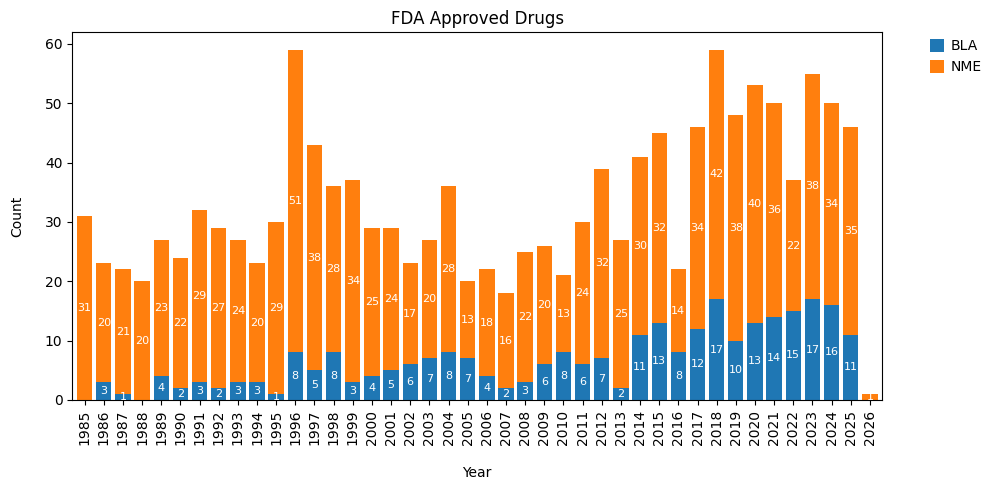

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [4]:
plot.stacked(legend_loc='out right upper')

Specific years can be sliced from the table for plotting. The start and end years are giving as a tuple.

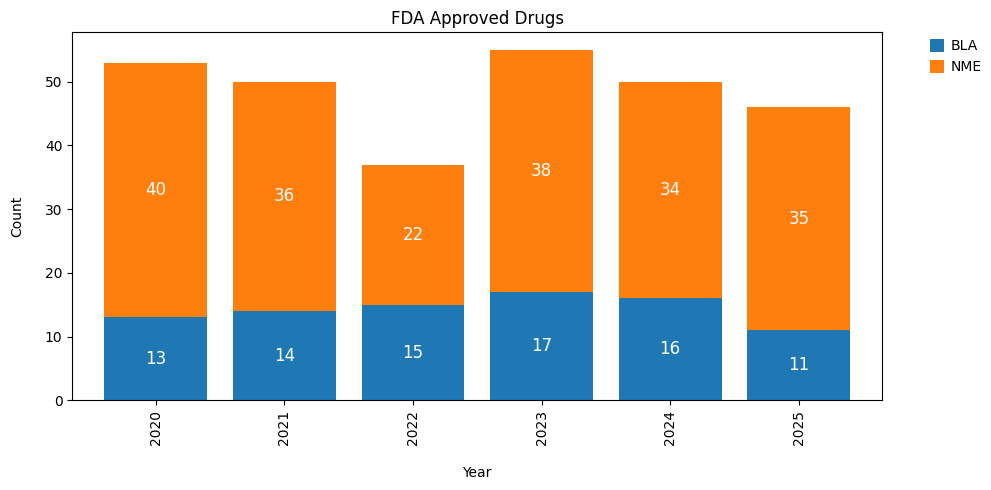

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [5]:
plot.stacked(years=(2020,2025), fontsize=12, legend_loc='out right upper')